In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
df = pd.read_csv("onlineretail.csv")

In [4]:
df_clean = df.copy()

In [5]:
df_clean.shape

(1067371, 8)

In [6]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
df_clean.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [8]:
df_clean.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [9]:
df_clean.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
Price,float64
Customer ID,float64
Country,object


In [10]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [11]:
df_clean.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [12]:
df_clean.duplicated().sum()

np.int64(34335)

In [13]:
df_clean = df_clean.drop_duplicates()

In [14]:
df_clean.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4275
Quantity,0
InvoiceDate,0
Price,0
Customer ID,235151
Country,0


In [15]:
(df_clean.isnull().sum()/len(df_clean))*100

,0
Invoice,0.000000
StockCode,0.000000
Description,0.413829
Quantity,0.000000
InvoiceDate,0.000000
Price,0.000000
Customer ID,22.763098
Country,0.000000


In [16]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

In [17]:
df_clean["Description"] = df_clean["Description"].str.strip()

In [18]:
df_clean["Country"] = df_clean["Country"].str.title()

In [19]:
df_clean["Country"] = df_clean["Country"].replace({
    "Unted Kingdom":"United Kingdom",
    "United Kngdom":"United Kingdom"
})

In [20]:
df_clean[df_clean["Price"]<0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [21]:
df_clean[df_clean["Price"] == 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
1062442,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom
1063965,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom
1063966,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom
1064015,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom


In [22]:
df_clean[df_clean["Quantity"] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [23]:
df_clean[df_clean["InvoiceDate"] > pd.Timestamp.today()]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [24]:
df_clean[df_clean["Description"] == " "]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [25]:
df_clean = df_clean.dropna()

In [26]:
df_clean["Price"] = df_clean["Price"].fillna(df_clean["Price"].mean())

In [27]:
df_clean["Country"].unique()

array(['United Kingdom', 'France', 'Usa', 'Belgium', 'Australia', 'Eire',
       'Germany', 'Portugal', 'Japan', 'Denmark', 'Netherlands', 'Poland',
       'Spain', 'Channel Islands', 'Italy', 'Cyprus', 'Greece', 'Norway',
       'Austria', 'Sweden', 'United Arab Emirates', 'Finland',
       'Switzerland', 'Unspecified', 'Nigeria', 'Malta', 'Rsa',
       'Singapore', 'Bahrain', 'Thailand', 'Israel', 'Lithuania',
       'West Indies', 'Korea', 'Brazil', 'Canada', 'Iceland', 'Lebanon',
       'Saudi Arabia', 'Czech Republic', 'European Community'],
      dtype=object)

In [28]:
df_clean["Country"].value_counts()

,count
Country,
United Kingdom,716115
Germany,17339
Eire,16014
France,13897
Netherlands,5137
Spain,3754
Belgium,3110
Switzerland,3058
Portugal,2414


In [29]:
df_clean.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,797885.000000,797885,797885.000000,797885.000000
mean,12.602980,2011-01-02 13:17:34.141160704,3.702732,15313.062777
min,-80995.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-07-02 09:47:00,1.250000,13964.000000
50%,5.000000,2010-12-02 12:33:00,1.950000,15228.000000
75%,12.000000,2011-07-31 15:50:00,3.750000,16788.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,191.670371,NaN,71.392549,1696.466663


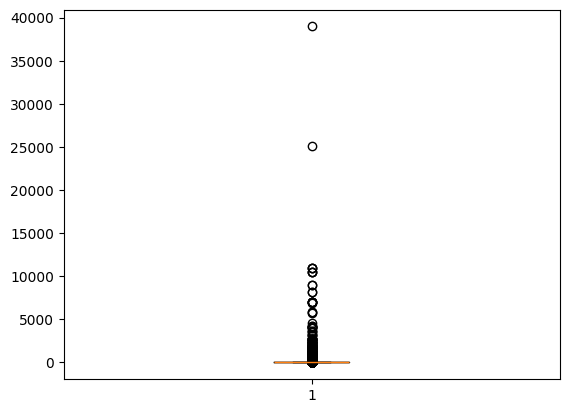

In [30]:
import matplotlib.pyplot as plt

plt.boxplot(df_clean["Price"])
plt.show()

In [31]:
df_clean.info()

df_clean.isnull().sum()

df_clean.duplicated().sum()

df_clean.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 797885 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      797885 non-null  object        
 1   StockCode    797885 non-null  object        
 2   Description  797885 non-null  object        
 3   Quantity     797885 non-null  int64         
 4   InvoiceDate  797885 non-null  datetime64[ns]
 5   Price        797885 non-null  float64       
 6   Customer ID  797885 non-null  float64       
 7   Country      797885 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 54.8+ MB


,Quantity,InvoiceDate,Price,Customer ID
count,797885.000000,797885,797885.000000,797885.000000
mean,12.602980,2011-01-02 13:17:34.141160704,3.702732,15313.062777
min,-80995.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-07-02 09:47:00,1.250000,13964.000000
50%,5.000000,2010-12-02 12:33:00,1.950000,15228.000000
75%,12.000000,2011-07-31 15:50:00,3.750000,16788.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,191.670371,NaN,71.392549,1696.466663


In [32]:
df_clean.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


In [33]:
df_clean.duplicated().sum()

np.int64(0)

In [34]:
df_clean.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,float64
Country,object


In [35]:
df_clean[df_clean["Price"] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [36]:
df_clean["Country"].value_counts()

,count
Country,
United Kingdom,716115
Germany,17339
Eire,16014
France,13897
Netherlands,5137
Spain,3754
Belgium,3110
Switzerland,3058
Portugal,2414


In [37]:
df_clean["Description"].isnull().sum()

np.int64(0)

In [38]:
df_clean = df_clean.dropna(subset=["Customer ID"]).copy()

In [39]:
df_clean.isnull().sum()
df_clean.duplicated().sum()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 797885 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      797885 non-null  object        
 1   StockCode    797885 non-null  object        
 2   Description  797885 non-null  object        
 3   Quantity     797885 non-null  int64         
 4   InvoiceDate  797885 non-null  datetime64[ns]
 5   Price        797885 non-null  float64       
 6   Customer ID  797885 non-null  float64       
 7   Country      797885 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 54.8+ MB


In [40]:
print(df_clean.duplicated().sum())

0


In [41]:
print(df_clean.isnull().sum())

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [42]:
df_clean.to_csv(r"C:\Users\valla\OneDrive\Desktop\OnlineRetail_Cleaned.csv", index=False)

In [43]:
df_clean.to_csv(r"C:\Users\valla\OneDrive\Desktop\CPI\Online_cleaned.csv", index=False)

In [44]:
import os

file_path = r"C:\Users\valla\OneDrive\Desktop\OnlineRetail_Cleaned.csv"

if os.path.exists(file_path):
    print("✅ File saved successfully!")
else:
    print("❌ File not found.")

✅ File saved successfully!


# **EDA ANALYSIS**

In [45]:
import pandas as pd

df = pd.read_csv("OnlineRetail_Cleaned.csv")

In [46]:
df.head()
df.tail()
df.shape
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 469214 entries, 0 to 469213
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      469214 non-null  object 
 1   StockCode    469214 non-null  object 
 2   Description  469214 non-null  object 
 3   Quantity     469214 non-null  float64
 4   InvoiceDate  469214 non-null  object 
 5   Price        469214 non-null  float64
 6   Customer ID  469214 non-null  float64
 7   Country      469214 non-null  object 
dtypes: float64(3), object(5)
memory usage: 28.6+ MB


Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [47]:
for column in df.columns:
  print(column)
  print(df[column].nunique())
  print("-"*40)

Invoice
27112
----------------------------------------
StockCode
4097
----------------------------------------
Description
4515
----------------------------------------
Quantity
522
----------------------------------------
InvoiceDate
25105
----------------------------------------
Price
710
----------------------------------------
Customer ID
4637
----------------------------------------
Country
40
----------------------------------------


In [48]:
df["totalsales"]=df["Quantity"]*df["Price"]

In [49]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df["month"]=df["InvoiceDate"].dt.month
df["Year"] = df["InvoiceDate"].dt.year
df["Day"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

In [50]:
df["totalsales"].sum()

np.float64(9575364.383999994)

In [51]:
df["Invoice"].nunique()

27112

In [52]:
df["Customer ID"].nunique()

4637

In [53]:
df["StockCode"].nunique()

4097

In [54]:
df["totalsales"].mean()

np.float64(20.407243569032456)

In [55]:
df['Quantity'].mean()

np.float64(12.886218228782603)

In [56]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [57]:
df_retail = pd.read_csv("OnlineRetail_Cleaned.csv")

In [58]:
df_retail['totalsales'] = df_retail['Quantity'] * df_retail['Price']

In [59]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [60]:
df_retail['InvoiceDate'] = pd.to_datetime(df_retail['InvoiceDate'])
df_retail['year']=df_retail['InvoiceDate'].dt.year

In [61]:
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Year"].unique()
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["Month"].unique()

array([12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], dtype=int32)

In [62]:
df_retail['monthname']=df_retail['InvoiceDate'].dt.month_name()

In [63]:
df_retail['monthname'].unique()

array(['December', 'January', 'February', 'March', 'April', 'May', 'June',
       'July', 'August', 'September', 'October', 'November'], dtype=object)

In [64]:
df_retail['dayname']=df_retail['InvoiceDate'].dt.day_name()

In [65]:
df_retail['dayname'].unique()

array(['Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday',
       'Monday'], dtype=object)

In [66]:
df_retail['hour']=df_retail['InvoiceDate'].dt.hour

In [67]:
df_retail['hour'].unique()

array([ 7,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,  8, 20, 21],
      dtype=int32)

In [68]:
df_retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,totalsales,year,monthname,dayname,hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,December,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,December,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,December,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,December,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,December,Tuesday,7


In [69]:
print("total Revenue:",df_retail['totalsales'].sum())

total Revenue: 9575364.383999994


In [70]:
print("total orders:",df_retail['Invoice'].nunique())

total orders: 27112


In [71]:
print("total customers:",df_retail['Customer ID'].nunique())

total customers: 4637


In [72]:
print("total products:",df_retail['StockCode'].nunique())

total products: 4097


In [73]:
print("average order value:",df_retail['totalsales'].mean())

average order value: 20.407243569032456


In [74]:
print("average product price:",df_retail['Price'].mean())

average product price: 3.8387304811876883


In [75]:
print("average quantity:",df_retail['Quantity'].mean())

average quantity: 12.886218228782603


In [76]:
df_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 469214 entries, 0 to 469213
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      469214 non-null  object        
 1   StockCode    469214 non-null  object        
 2   Description  469214 non-null  object        
 3   Quantity     469214 non-null  float64       
 4   InvoiceDate  469214 non-null  datetime64[ns]
 5   Price        469214 non-null  float64       
 6   Customer ID  469214 non-null  float64       
 7   Country      469214 non-null  object        
 8   totalsales   469214 non-null  float64       
 9   year         469214 non-null  int32         
 10  monthname    469214 non-null  object        
 11  dayname      469214 non-null  object        
 12  hour         469214 non-null  int32         
dtypes: datetime64[ns](1), float64(4), int32(2), object(6)
memory usage: 43.0+ MB


unvariant analysis

In [77]:
print(df_retail['Quantity'].describe())

count    469214.000000
mean         12.886218
std         181.339890
min      -74215.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       74215.000000
Name: Quantity, dtype: float64


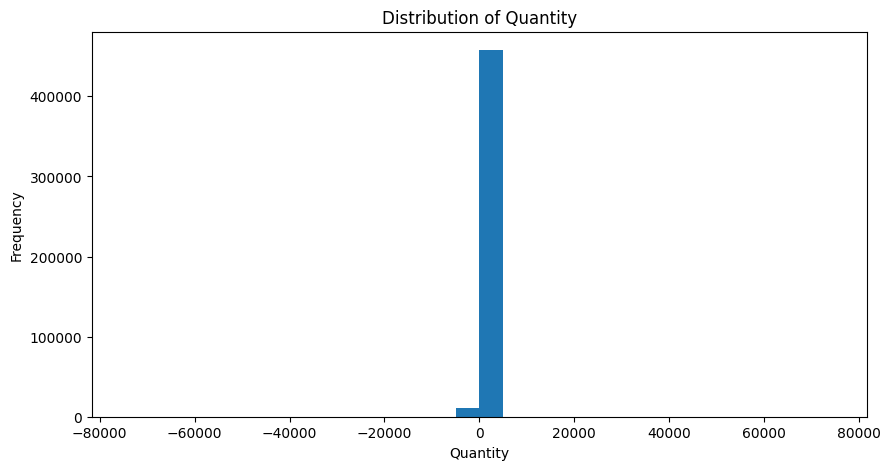

In [78]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.hist(df_retail['Quantity'],bins=30)
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

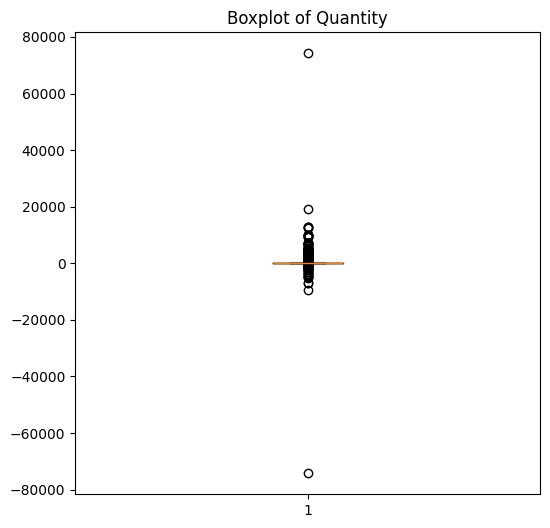

In [79]:
plt.figure(figsize=(6,6))
plt.boxplot(df_retail['Quantity'])
plt.title('Boxplot of Quantity')
plt.show()

In [80]:
print(df_retail['Price'].describe())

count    469214.000000
mean          3.838730
std          67.222962
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max       25111.090000
Name: Price, dtype: float64


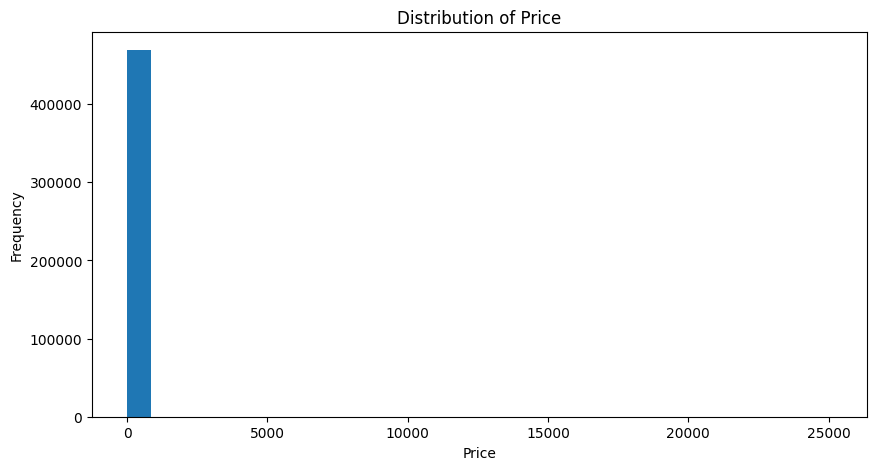

In [81]:
plt.figure(figsize=(10,5))
plt.hist(df_retail['Price'],bins=30)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

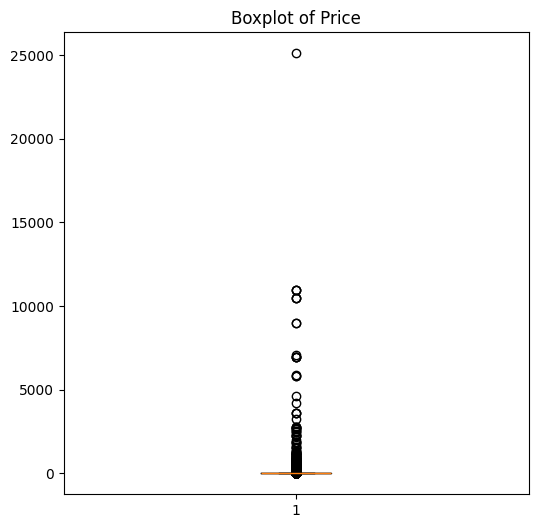

In [82]:
plt.figure(figsize=(6,6))
plt.boxplot(df_retail['Price'])
plt.title('Boxplot of Price')
plt.show()

In [83]:
print(df_retail['totalsales'].describe())

count    469214.000000
mean         20.407244
std         187.155572
min      -77183.600000
25%           4.950000
50%          11.800000
75%          19.500000
max       77183.600000
Name: totalsales, dtype: float64


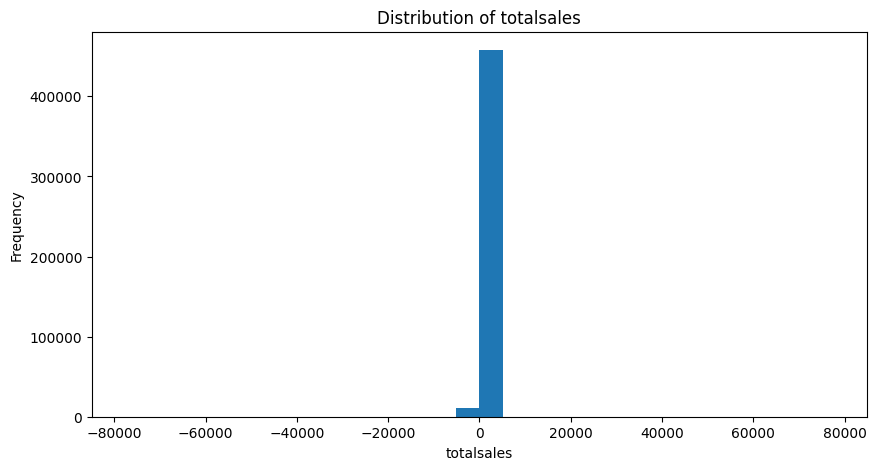

In [84]:
plt.figure(figsize=(10,5))
plt.hist(df_retail['totalsales'],bins=30)
plt.title('Distribution of totalsales')
plt.xlabel('totalsales')
plt.ylabel('Frequency')
plt.show()
#

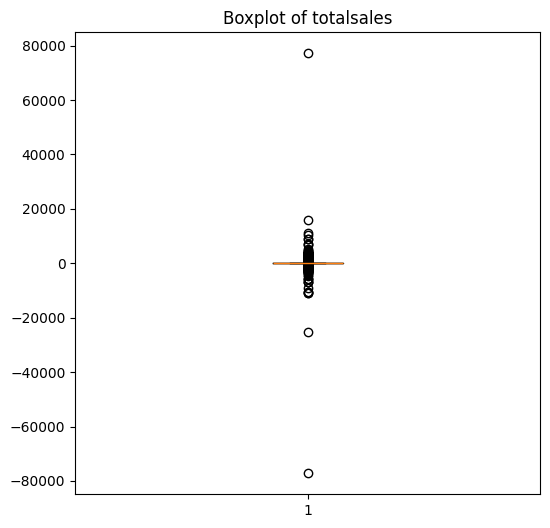

In [85]:
plt.figure(figsize=(6,6))
plt.boxplot(df_retail['totalsales'])
plt.title('Boxplot of totalsales')
plt.show()

In [86]:
print("Quantity skewness:",df_retail['Quantity'].skew())
print("Price skewness:",df_retail['Price'].skew())
print("totalsales skewness:",df_retail['totalsales'].skew())

Quantity skewness: 9.627801238644341
Price skewness: 193.99951554433403
totalsales skewness: -4.134678021719638


In [87]:
print("Quantity kurtosis:",df_retail['Quantity'].kurt())
print("Price kurtosis:",df_retail['Price'].kurt())
print("totalsales kurtosis:",df_retail['totalsales'].kurt())

Quantity kurtosis: 120287.49368989961
Price kurtosis: 52906.956537216916
totalsales kurtosis: 124316.197371049


categorical analysis

In [88]:
country_transactions = df_retail['Country'].value_counts()
print(country_transactions)

Country
United Kingdom          423880
Germany                   9667
Eire                      9523
France                    7066
Netherlands               3258
Spain                     1809
Switzerland               1493
Belgium                   1364
Portugal                  1242
Channel Islands            987
Australia                  968
Sweden                     956
Italy                      891
Cyprus                     801
Finland                    588
Austria                    571
Greece                     571
Denmark                    448
Norway                     412
Japan                      370
United Arab Emirates       348
Unspecified                280
Poland                     247
Usa                        244
Singapore                  173
Malta                      172
Lithuania                  154
Iceland                    100
Israel                      92
Canada                      77
Thailand                    76
Rsa                         65


In [89]:
country_transactions.head(10)

,count
Country,
United Kingdom,423880
Germany,9667
Eire,9523
France,7066
Netherlands,3258
Spain,1809
Switzerland,1493
Belgium,1364
Portugal,1242


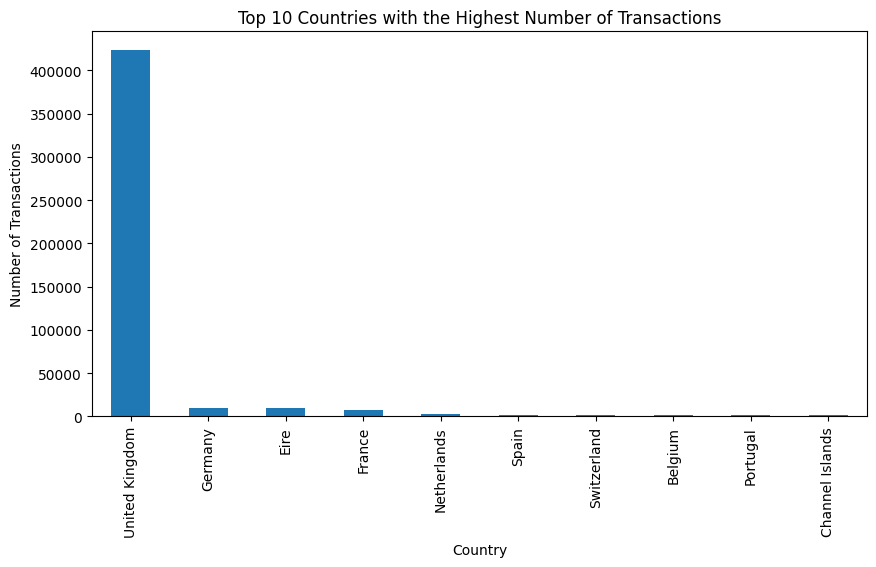

In [90]:
country_transactions.head(10).plot(kind='bar',figsize=(10,5))
plt.title('Top 10 Countries with the Highest Number of Transactions')
plt.xlabel('Country')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=90)
plt.show()

In [91]:
country_sales=df_retail.groupby('Country')['totalsales'].sum()
country_sales=country_sales.sort_values(ascending=False)
print(country_sales.head(10))

Country
United Kingdom    7985134.993
Eire               364268.630
Netherlands        321996.910
Germany            232357.541
France             160956.220
Australia           70575.570
Sweden              57438.230
Switzerland         51218.830
Spain               47845.180
Denmark             47372.170
Name: totalsales, dtype: float64


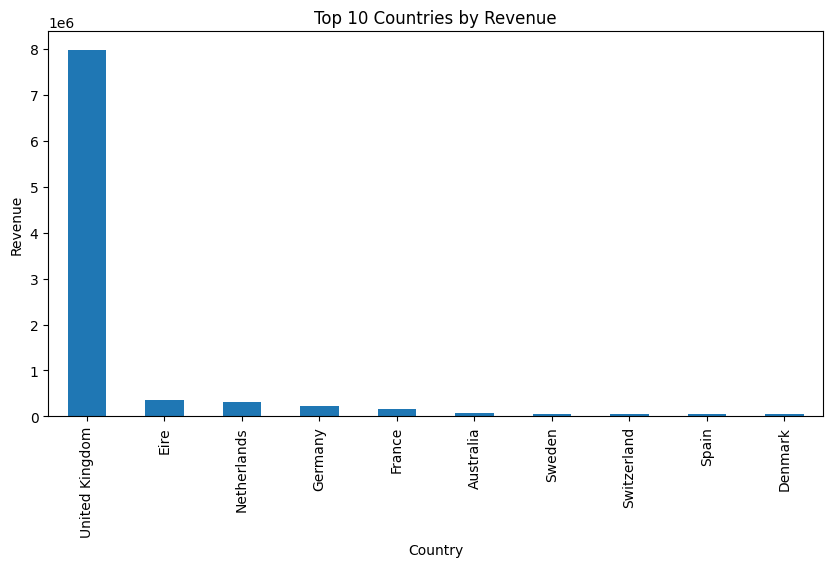

In [92]:
country_sales.head(10).plot(kind='bar',figsize=(10,5))
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=90)
plt.show()

In [93]:
top_products = (
    df_retail.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)

)
print(top_products.head(10))


Description
WHITE HANGING HEART T-LIGHT HOLDER    64660.0
WORLD WAR 2 GLIDERS ASSTD DESIGNS     62150.0
BROCADE RING PURSE                    51253.0
ASSORTED COLOUR BIRD ORNAMENT         48470.0
PACK OF 72 RETRO SPOT CAKE CASES      44480.0
60 TEATIME FAIRY CAKE CASES           38383.0
JUMBO BAG RED RETROSPOT               36118.0
PACK OF 60 PINK PAISLEY CAKE CASES    34205.0
SMALL POPCORN HOLDER                  31009.0
PACK OF 72 SKULL CAKE CASES           26934.0
Name: Quantity, dtype: float64


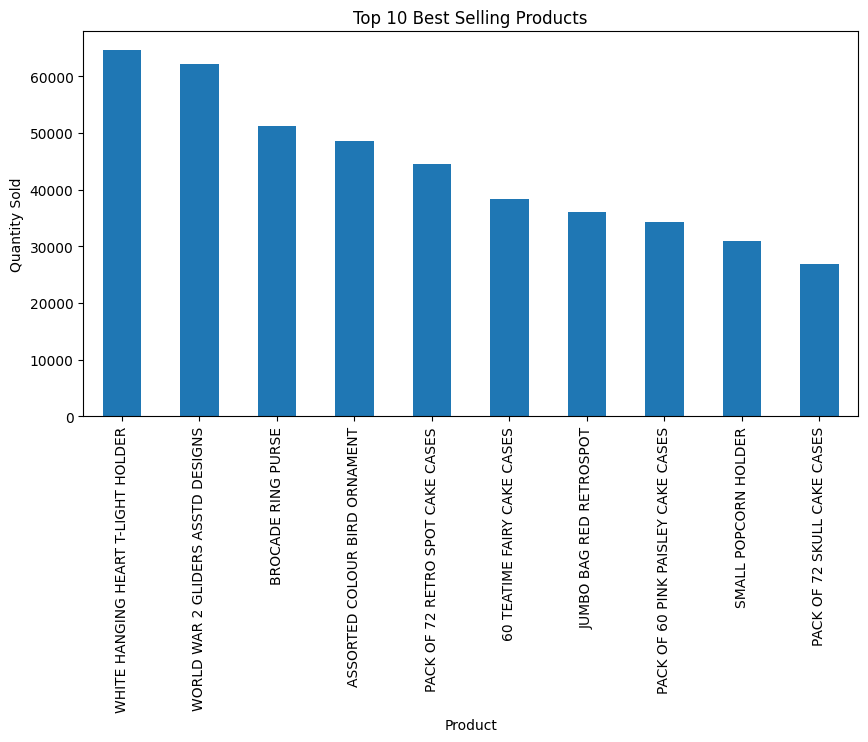

In [94]:
top_products.head(10).plot(kind='bar',figsize=(10,5))
plt.title('Top 10 Best Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=90)
plt.show()


In [95]:
top_products_revenue = (
    df_retail.groupby('Description')['totalsales']
    .sum()
    .sort_values(ascending=False)
)
print(top_products_revenue.head(10))

Description
WHITE HANGING HEART T-LIGHT HOLDER     172852.21
REGENCY CAKESTAND 3 TIER               167406.60
ASSORTED COLOUR BIRD ORNAMENT           76849.34
JUMBO BAG RED RETROSPOT                 63194.70
POSTAGE                                 56661.16
VINTAGE UNION JACK BUNTING              42071.23
ROTATING SILVER ANGELS T-LIGHT HLDR     41811.60
PARTY BUNTING                           41154.95
JUMBO BAG STRAWBERRY                    38782.80
PAPER CHAIN KIT 50'S CHRISTMAS          38660.20
Name: totalsales, dtype: float64


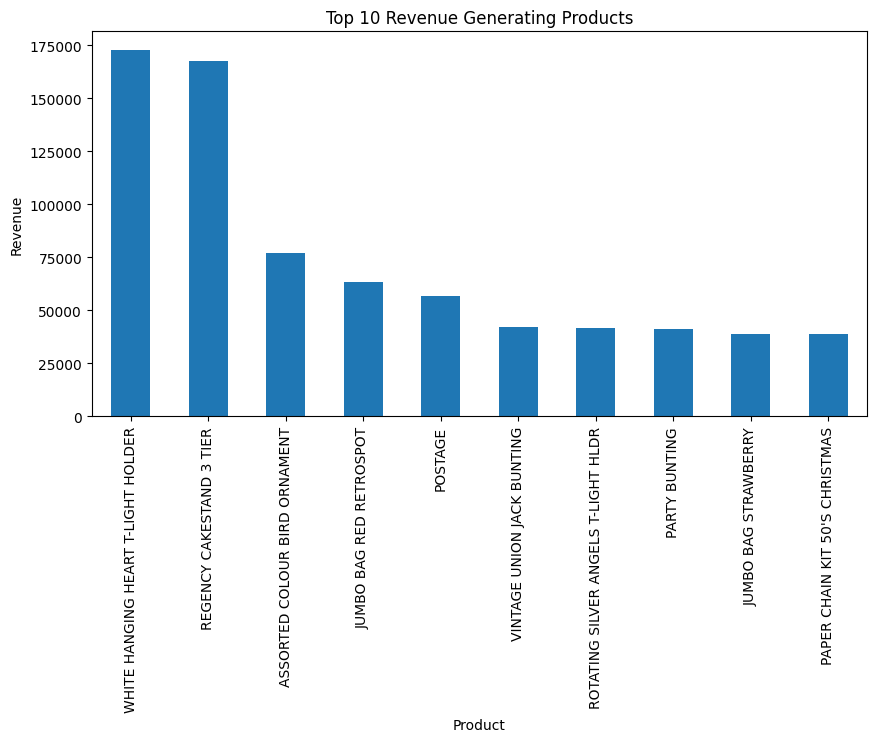

In [96]:
top_products_revenue.head(10).plot(kind='bar',figsize=(10,5))
plt.title('Top 10 Revenue Generating Products')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=90)
plt.show()

In [97]:
top_customers = (
    df_retail.groupby('Customer ID')['Invoice']
    .nunique()
    .sort_values(ascending=False)
)
print(top_customers.head(10))

Customer ID
14911.0    292
15311.0    188
12748.0    187
14606.0    170
17850.0    159
13089.0    158
17841.0    151
14156.0    146
14527.0    125
13694.0    116
Name: Invoice, dtype: int64


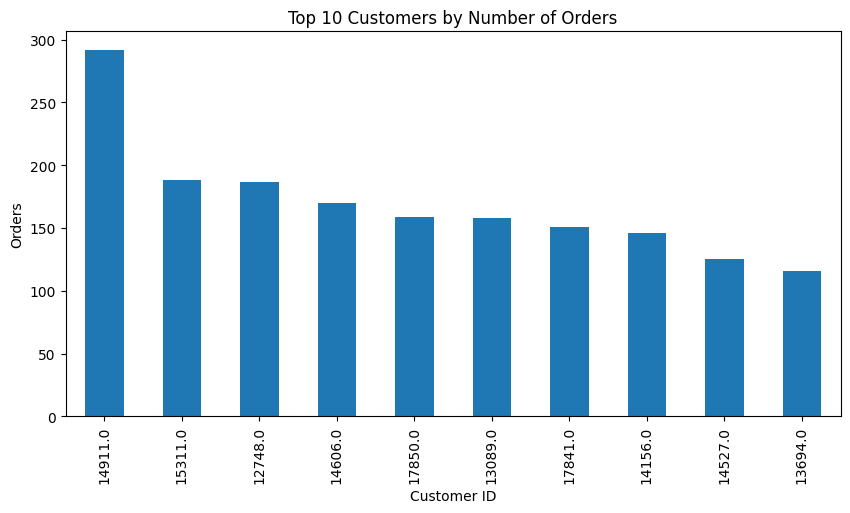

In [98]:
top_customers.head(10).plot(kind='bar',figsize=(10,5))
plt.title('Top 10 Customers by Number of Orders')
plt.xlabel('Customer ID')
plt.ylabel('Orders')
plt.show()

In [99]:
customer_revenue =(
    df_retail.groupby('Customer ID')['totalsales']
    .sum()
    .sort_values(ascending=False)
)
print(customer_revenue.head(10))


Customer ID
18102.0    353708.21
14646.0    301674.07
14156.0    208570.95
14911.0    147583.99
13694.0    141635.80
17511.0     98535.13
15061.0     94154.18
16684.0     85269.51
13089.0     67504.13
15311.0     67471.45
Name: totalsales, dtype: float64


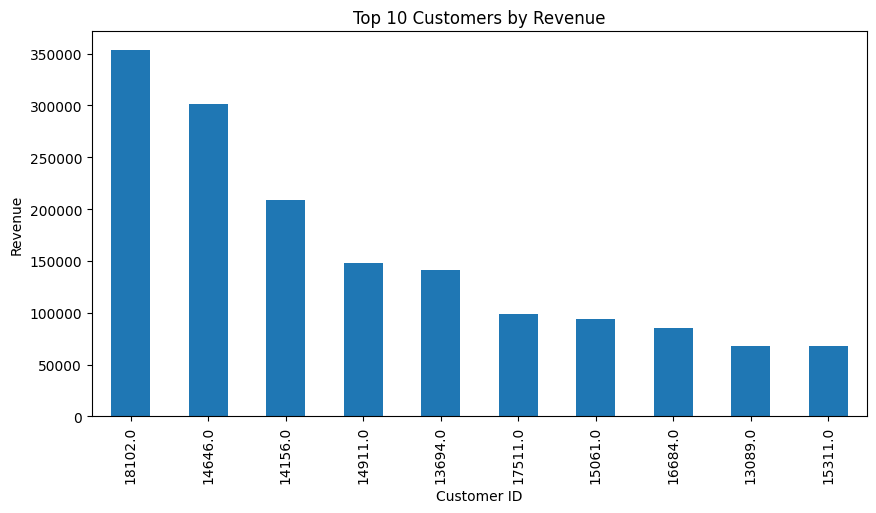

In [100]:
customer_revenue.head(10).plot(kind='bar',figsize=(10,5))
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.show()

In [101]:
print(df_retail['Description'].nunique())

4515


In [102]:
print(df_retail['StockCode'].nunique())

4097


In [103]:
print(df_retail['Invoice'].nunique())

27112


In [104]:
orders_country =(
    df_retail.groupby('Country')['Invoice']
    .nunique()
    .sort_values(ascending=False)
)
print(orders_country.head(10))


Country
United Kingdom    24629
Germany             611
Eire                449
France              375
Netherlands         164
Spain               105
Sweden               89
Belgium              87
Australia            69
Portugal             67
Name: Invoice, dtype: int64


time series analysis

In [105]:
df_retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,totalsales,year,monthname,dayname,hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,December,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,December,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,December,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,December,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,December,Tuesday,7


In [106]:
monthly_sales = (
    df_retail.groupby('monthname')['totalsales']
    .sum()
)
print(monthly_sales)

monthname
April         558007.832
August        585259.460
December     1212497.960
February      923130.496
January      1004168.412
July          560885.330
June          568784.550
March         735691.001
May           557873.390
November     1129025.162
October       961520.740
September     778520.051
Name: totalsales, dtype: float64


In [107]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
monthly_sales =(
    df_retail.groupby('monthname')['totalsales']
    .sum()
    .reindex(month_order)
)
print(monthly_sales)


monthname
January      1004168.412
February      923130.496
March         735691.001
April         558007.832
May           557873.390
June          568784.550
July          560885.330
August        585259.460
September     778520.051
October       961520.740
November     1129025.162
December     1212497.960
Name: totalsales, dtype: float64


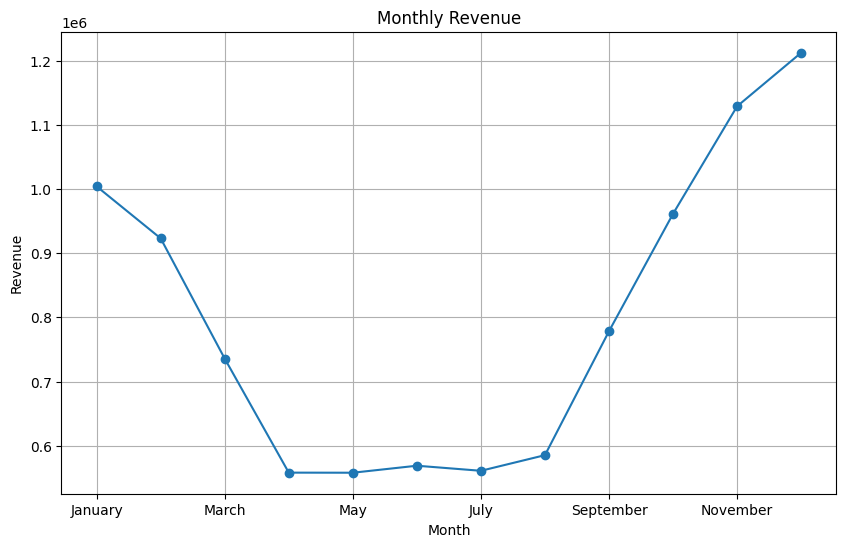

In [108]:
monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10, 6),
)
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

In [109]:
monthly_orders =(
    df_retail.groupby('monthname')['Invoice']
    .nunique()
    .reindex(month_order)
)
print(monthly_orders)


monthname
January      2532
February     2537
March        2187
April        1615
May          1768
June         1833
July         1713
August       1547
September    2041
October      2586
November     3145
December     3608
Name: Invoice, dtype: int64


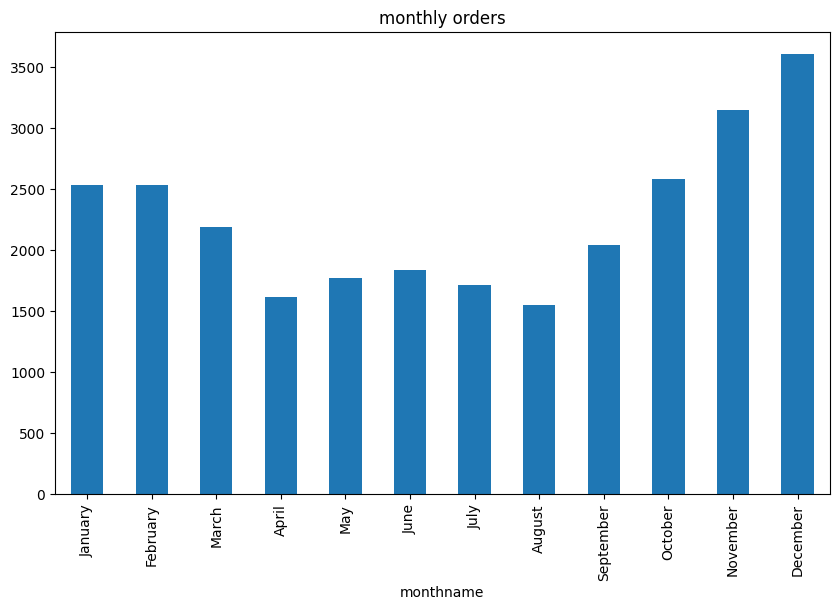

In [110]:
monthly_orders.plot(
    kind='bar',
    figsize=(10, 6),
)
plt.title("monthly orders")
plt.show()

In [111]:
day_order =[
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]
weekday_sales = (
    df_retail.groupby('dayname')['totalsales']
    .sum()
    .reindex(day_order)
)
print(weekday_sales)


dayname
Monday       1604526.895
Tuesday      1821464.431
Wednesday    1680164.013
Thursday     1945726.112
Friday       1410464.392
Saturday        9803.050
Sunday       1103215.491
Name: totalsales, dtype: float64


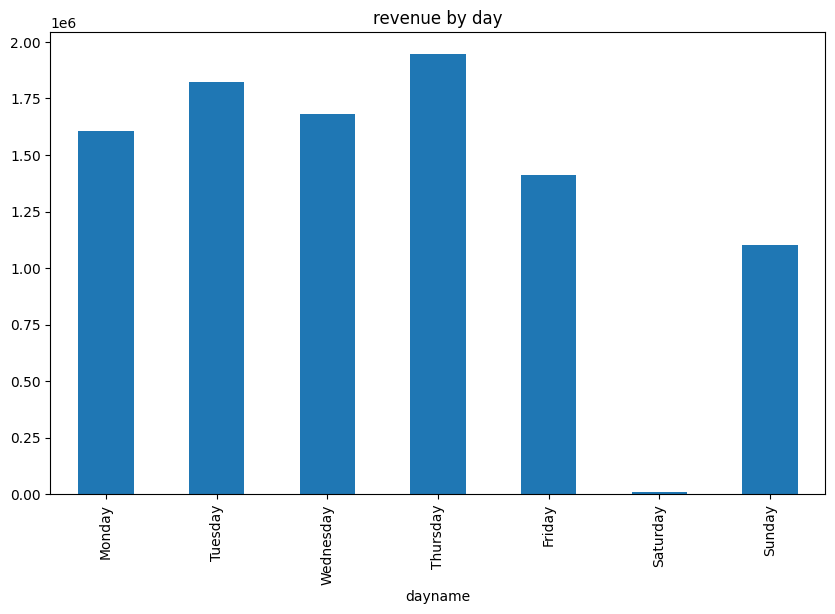

In [112]:
weekday_sales.plot(
    kind='bar',
    figsize=(10,6)
)
plt.title("revenue by day")
plt.show()

In [113]:
weekday_orders = (
    df_retail.groupby('dayname')['Invoice']
    .nunique()
    .reindex(day_order)
)
print(weekday_orders)


dayname
Monday       4155
Tuesday      5219
Wednesday    4802
Thursday     5723
Friday       3929
Saturday       30
Sunday       3254
Name: Invoice, dtype: int64


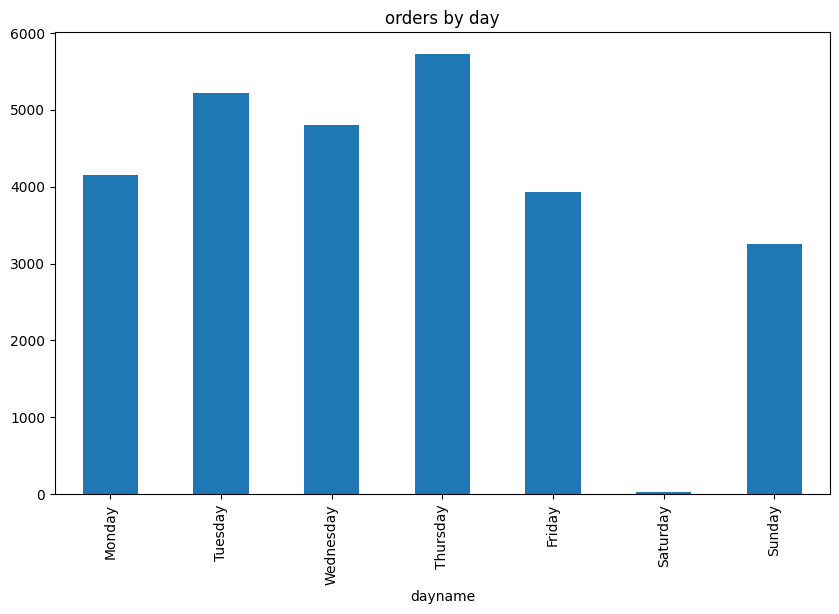

In [114]:
weekday_orders.plot(
    kind='bar',
    figsize=(10,6)
)
plt.title("orders by day")
plt.show()

In [115]:
hourly_sales = (
    df_retail.groupby('hour')['totalsales']
    .sum()
)
print(hourly_sales)

hour
7       44269.400
8      278362.780
9      769027.400
10    1238044.912
11    1248375.103
12    1541806.491
13    1329493.234
14    1101085.580
15     965063.052
16     620005.111
17     259616.611
18      82965.120
19      77897.200
20      19357.340
21         -4.950
Name: totalsales, dtype: float64


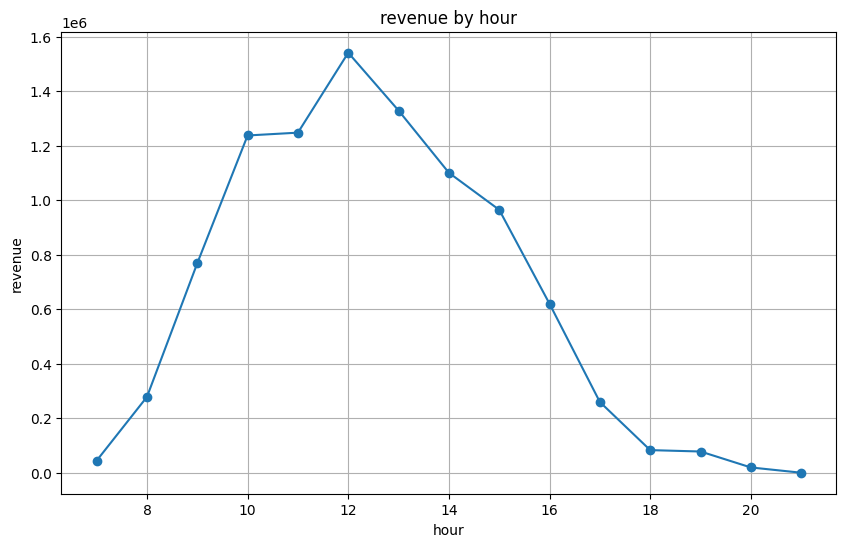

In [116]:
hourly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10,6)
)
plt.title("revenue by hour")
plt.xlabel("hour")
plt.ylabel("revenue")
plt.grid(True)
plt.show()


In [117]:
hourly_orders =(
    df_retail.groupby('hour')['Invoice']
    .nunique()
)
print(hourly_orders)


hour
7       82
8      599
9     1714
10    3113
11    3474
12    4259
13    3873
14    3252
15    2888
16    1900
17    1086
18     443
19     357
20      71
21       1
Name: Invoice, dtype: int64


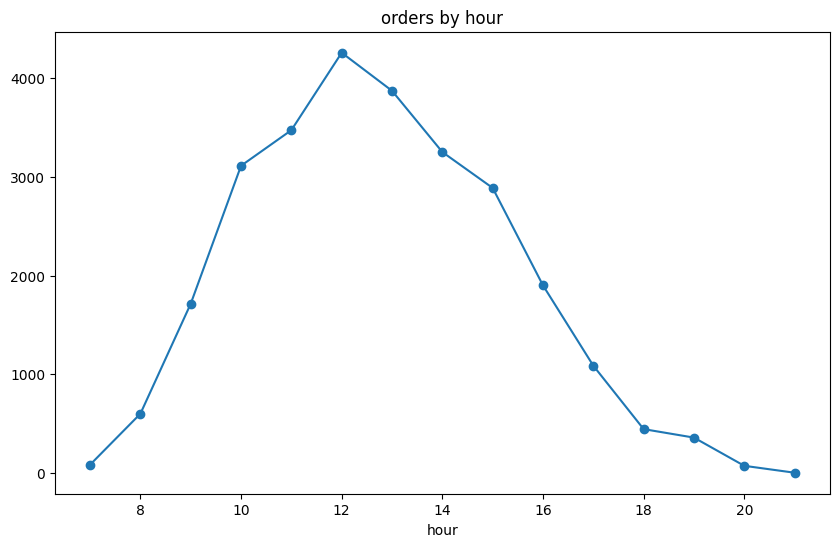

In [118]:
hourly_orders.plot(
    kind='line',
    marker='o',
    figsize=(10,6)
)
plt.title("orders by hour")
plt.show()


In [119]:
yearly_sales=(
    df_retail.groupby('year')['totalsales']
    .sum()
)
print(yearly_sales)


year
2009     660125.100
2010    7903701.624
2011    1011537.660
Name: totalsales, dtype: float64


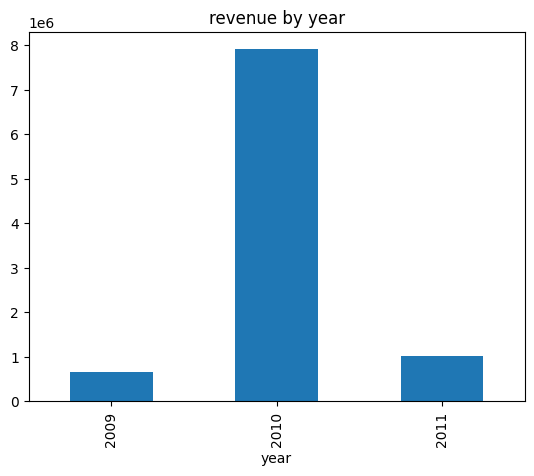

In [120]:
yearly_sales.plot(
    kind='bar'
)
plt.title("revenue by year")
plt.show()

In [121]:
daily_sales =(
    df_retail.groupby('InvoiceDate')['totalsales']
    .sum()
)
print(daily_sales)


InvoiceDate
2009-12-01 07:45:00     505.30
2009-12-01 07:46:00     145.80
2009-12-01 09:06:00     630.33
2009-12-01 09:08:00     310.75
2009-12-01 09:24:00    2286.24
                        ...   
2011-03-07 09:10:00     219.30
2011-03-07 09:35:00     673.90
2011-03-07 09:39:00     142.28
2011-03-07 09:49:00     282.66
2011-03-07 09:52:00     430.50
Name: totalsales, Length: 25105, dtype: float64


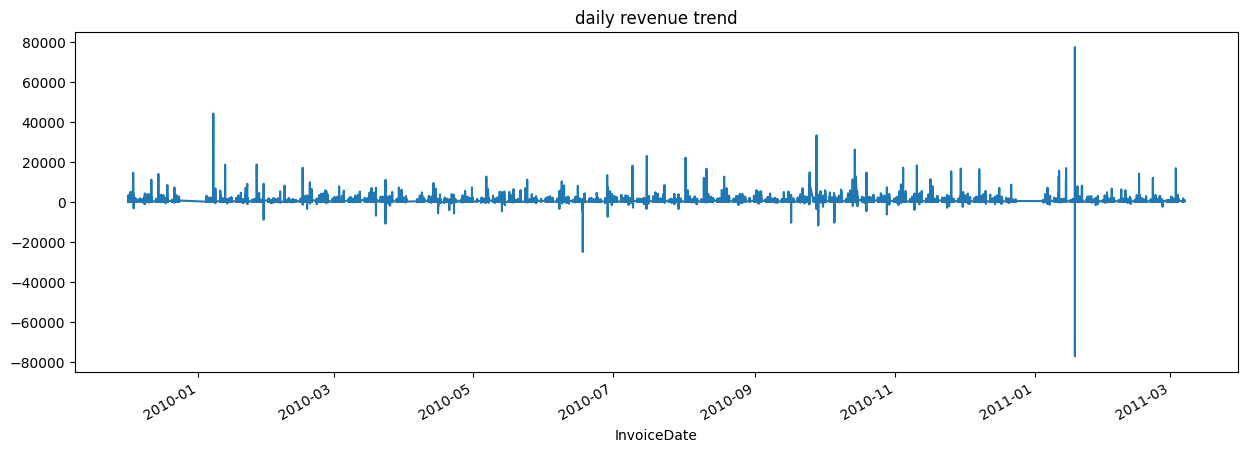

In [122]:
daily_sales.plot(
    figsize=(15,5)
)
plt.title("daily revenue trend")
plt.show()

correlation & relationship analysis

In [123]:
numeric_df = df_retail[["Quantity", "Price", "totalsales"]]

In [124]:
print(numeric_df.corr())

            Quantity     Price  totalsales
Quantity    1.000000 -0.002384    0.813943
Price      -0.002384  1.000000   -0.192315
totalsales  0.813943 -0.192315    1.000000


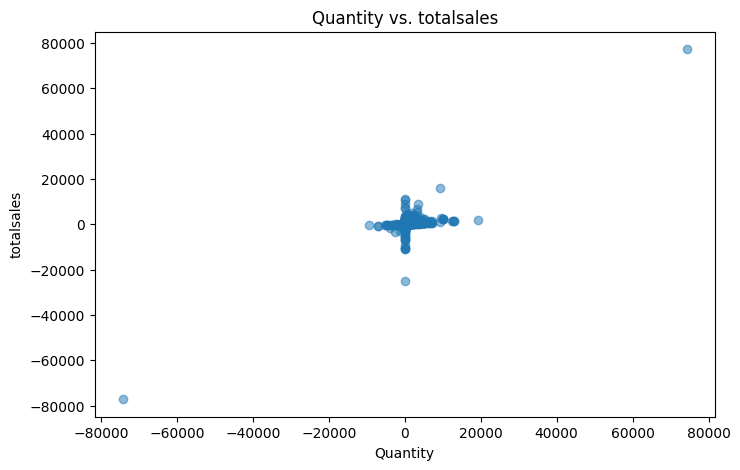

In [125]:
plt.figure(figsize=(8,5))
plt.scatter(
    df_retail["Quantity"],
    df_retail["totalsales"],
    alpha=0.5
)
plt.title("Quantity vs. totalsales")
plt.xlabel("Quantity")
plt.ylabel("totalsales")
plt.show()


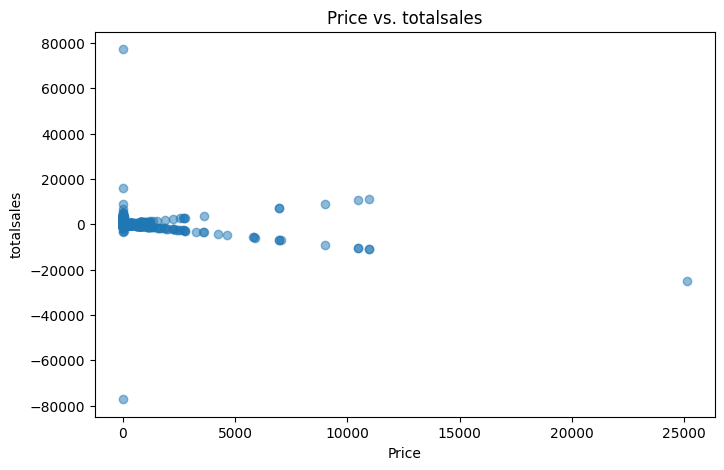

In [133]:
plt.figure(figsize=(8,5))
plt.scatter(
    df_retail["Price"],
    df_retail["totalsales"],
    alpha=0.5
)
plt.title("Price vs. totalsales")
plt.xlabel("Price")
plt.ylabel("totalsales")
plt.show()



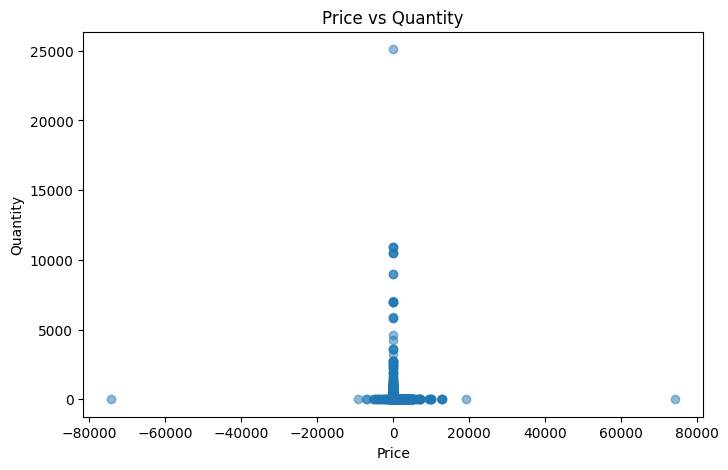

In [127]:
plt.figure(figsize=(8,5))
plt.scatter(
    df_retail["Quantity"],
    df_retail["Price"],
    alpha=0.5
)
plt.title("Price vs Quantity")
plt.ylabel("Quantity")
plt.xlabel("Price")
plt.show()

In [128]:
country_sales =(
    df_retail.groupby('Country')['totalsales']
    .sum()
    .sort_values(ascending=False)
)
print(country_sales.head(10))

Country
United Kingdom    7985134.993
Eire               364268.630
Netherlands        321996.910
Germany            232357.541
France             160956.220
Australia           70575.570
Sweden              57438.230
Switzerland         51218.830
Spain               47845.180
Denmark             47372.170
Name: totalsales, dtype: float64


In [129]:
product_sales =(
    df_retail.groupby('Description')['totalsales']
    .sum()
    .sort_values(ascending=False)
)
print(product_sales.head(10))

Description
WHITE HANGING HEART T-LIGHT HOLDER     172852.21
REGENCY CAKESTAND 3 TIER               167406.60
ASSORTED COLOUR BIRD ORNAMENT           76849.34
JUMBO BAG RED RETROSPOT                 63194.70
POSTAGE                                 56661.16
VINTAGE UNION JACK BUNTING              42071.23
ROTATING SILVER ANGELS T-LIGHT HLDR     41811.60
PARTY BUNTING                           41154.95
JUMBO BAG STRAWBERRY                    38782.80
PAPER CHAIN KIT 50'S CHRISTMAS          38660.20
Name: totalsales, dtype: float64


In [130]:
customer_sales =(
    df_retail.groupby('Customer ID')['totalsales']
    .sum()
    .sort_values(ascending=False)
)
print(customer_sales.head(10))

Customer ID
18102.0    353708.21
14646.0    301674.07
14156.0    208570.95
14911.0    147583.99
13694.0    141635.80
17511.0     98535.13
15061.0     94154.18
16684.0     85269.51
13089.0     67504.13
15311.0     67471.45
Name: totalsales, dtype: float64


In [131]:
avg_price_country=(
    df_retail.groupby('Country')['Price']
    .mean()
    .sort_values(ascending=False)
)
print(avg_price_country.head(10))

Country
Norway             88.534345
Malta              34.358023
Eire                7.857104
Unspecified         7.606964
Sweden              7.371590
Spain               7.099602
Belgium             6.154516
Italy               5.915443
Channel Islands     5.757366
Cyprus              5.715930
Name: Price, dtype: float64


In [132]:
avg_quantity = (
    df_retail.groupby('Country')['Quantity']
    .mean()
    .sort_values(ascending=False)
)
print(avg_quantity.head(10))


Country
Denmark           507.263393
Netherlands        69.156845
Sweden             61.870293
Australia          46.116736
Thailand           33.578947
Japan              32.321622
Czech Republic     23.066667
Eire               20.254437
Norway             19.864078
Switzerland        17.920295
Name: Quantity, dtype: float64


In [137]:
df_retail.to_csv("Retail_EDA.csv", index=False)

In [135]:
import pandas as pd

df = pd.read_csv("Retail_EDA.csv")

In [138]:
df_retails = pd.read_csv("Retail_EDA.csv")

In [139]:
df_retails.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,totalsales,year,monthname,dayname,hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,December,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,December,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,December,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,December,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,December,Tuesday,7


In [141]:
df_retails.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'totalsales', 'year', 'monthname',
       'dayname', 'hour'],
      dtype='object')